In [ ]:
import numpy as np
import pandas as pd

In [10]:
df = pd.read_csv(r"C:\Users\bobs9\OneDrive\Desktop\Data science and Machine learning\Day_wise_learning\Day_26\titanic.csv") 

Using IQR

<Axes: >

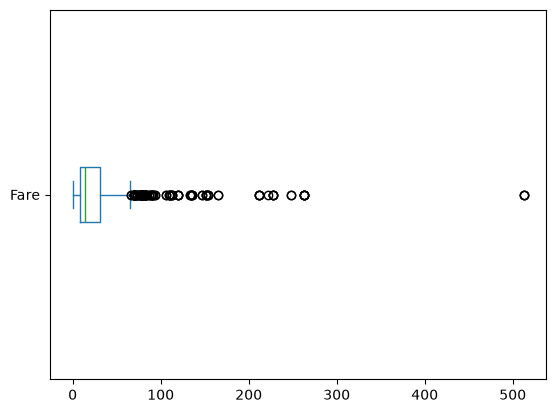

In [11]:
df['Fare'].plot(kind = 'box' , vert = False)

In [12]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

# Define limits
lower_whisker = Q1 - (1.5 * IQR)
upper_whisker = Q3 + (1.5 * IQR)

# Capping outliers
df['Fare'] = np.where(
    df['Fare'] > upper_whisker,
    upper_whisker,
    np.where(df['Fare'] < lower_whisker, lower_whisker, df['Fare']),
)

In [15]:
print(lower_whisker,upper_whisker)

-26.724 65.6344


In [17]:
outliers = df[(df['Fare'] < lower_whisker) | (df['Fare'] > upper_whisker)]
outliers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


<Axes: >

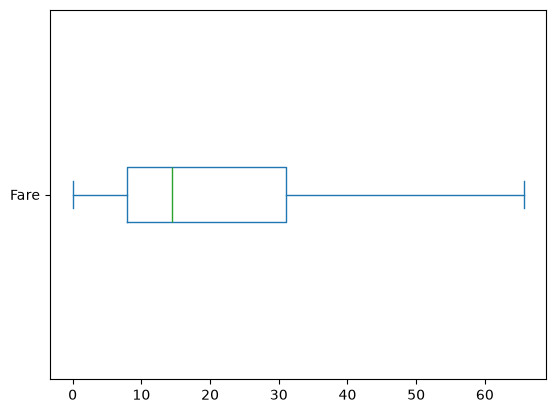

In [14]:
df['Fare'].plot(kind = 'box' , vert = False)

Fill then find outlier in df["Age"]

In [ ]:
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

In [ ]:
Q1 = df['Age'].quantile(0.25)   
Q3 = df['Age'].quantile(0.75)   
IQR = Q3 - Q1

lower_fence = Q1 - (1.5 * IQR)
upper_fence = Q3 + (1.5 * IQR)  

print(f"Lower Fence: {lower_fence:.2f} | Upper Fence: {upper_fence:.2f}")

Lower Fence: -6.69 | Upper Fence: 64.81


In [20]:
age_outliers = df[(df['Age'] < lower_fence) | (df['Age'] > upper_fence)]

print(f"Total outliers detected after imputation: {len(age_outliers)}")
print(age_outliers[['Pclass', 'Age', 'Survived']].head())

Total outliers detected after imputation: 11
     Pclass   Age  Survived
33        2  66.0         0
54        1  65.0         0
96        1  71.0         0
116       3  70.5         0
280       3  65.0         0


Z-Score

In [21]:
age_mean = df['Age'].mean()
age_std = df['Age'].std()


df['Age_Zscore'] = (df['Age'] - age_mean) / age_std


age_z_outliers = df[np.abs(df['Age_Zscore']) > 3]

print(f"Mean Age: {age_mean:.2f} | Std Dev: {age_std:.2f}")
print(f"Number of Z-score outliers found: {len(age_z_outliers)}")
print(age_z_outliers[['Pclass', 'Age', 'Age_Zscore']].head())

Mean Age: 29.70 | Std Dev: 14.53
Number of Z-score outliers found: 2
     Pclass   Age  Age_Zscore
630       1  80.0    3.462699
851       3  74.0    3.049660
